Hola **Lorena**!

Soy **Patricio Requena** 👋. Es un placer ser el revisor de tu proyecto el día de hoy!

Revisaré tu proyecto detenidamente con el objetivo de ayudarte a mejorar y perfeccionar tus habilidades. Durante mi revisión, identificaré áreas donde puedas hacer mejoras en tu código, señalando específicamente qué y cómo podrías ajustar para optimizar el rendimiento y la claridad de tu proyecto. Además, es importante para mí destacar los aspectos que has manejado excepcionalmente bien. Reconocer tus fortalezas te ayudará a entender qué técnicas y métodos están funcionando a tu favor y cómo puedes aplicarlos en futuras tareas. 

_**Recuerda que al final de este notebook encontrarás un comentario general de mi parte**_, empecemos!

Encontrarás mis comentarios dentro de cajas verdes, amarillas o rojas, ⚠️ **por favor, no muevas, modifiques o borres mis comentarios** ⚠️:


<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si todo está perfecto.
</div>

<div class="alert alert-block alert-warning">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si tu código está bien pero se puede mejorar o hay algún detalle que le hace falta.
</div>

<div class="alert alert-block alert-danger">
<b>Comentario del revisor</b> <a class=“tocSkip”></a>
Si de pronto hace falta algo o existe algún problema con tu código o conclusiones.
</div>

Puedes responderme de esta forma:
<div class="alert alert-block alert-info">
<b>Respuesta del estudiante</b> <a class=“tocSkip”></a>
</div>

# Sprint 12 - Proyecto

### 1. Preparacion de los datos
#### 1.1 Abrir los archivos y examinarlos 

In [1]:
#importar las librerias necesarias
import pandas as pd
import numpy as np
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import make_scorer

In [30]:
# Cargar datasets
train = pd.read_csv('/datasets/gold_recovery_train.csv', index_col='date', parse_dates=True)
test = pd.read_csv('/datasets/gold_recovery_test.csv', index_col='date', parse_dates=True)
full = pd.read_csv('/datasets/gold_recovery_full.csv', index_col='date', parse_dates=True)

# Primer vistazo
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("Full shape:", full.shape)

print("\nTrain head:\n", train.head())
print("\nTest head:\n", test.head())
print("\nFull head:\n", full.head())

# Revisar valores nulos
print("\nMissing values in train:\n", train.isna().sum().sort_values(ascending=False).head(10))
print("\nMissing values in test:\n", test.isna().sum().sort_values(ascending=False).head(10))
print("\nMissing values in full:\n", full.isna().sum().sort_values(ascending=False).head(10))

Train shape: (16860, 86)
Test shape: (5856, 52)
Full shape: (22716, 86)

Train head:
                      final.output.concentrate_ag  final.output.concentrate_pb  \
date                                                                            
2016-01-15 00:00:00                     6.055403                     9.889648   
2016-01-15 01:00:00                     6.029369                     9.968944   
2016-01-15 02:00:00                     6.055926                    10.213995   
2016-01-15 03:00:00                     6.047977                     9.977019   
2016-01-15 04:00:00                     6.148599                    10.142511   

                     final.output.concentrate_sol  \
date                                                
2016-01-15 00:00:00                      5.507324   
2016-01-15 01:00:00                      5.257781   
2016-01-15 02:00:00                      5.383759   
2016-01-15 03:00:00                      4.858634   
2016-01-15 04:00:00         

Se puede observar que:
- Dimensiones:
    - train tiene 16860 filas por 86 features
    - test tiene 5856 filas por 52 features
    - full tiene 22716 filas por 86 features
- Linea de tiempo:
    - train empieza en 2016-01-15 00:00:00
    - test empieza en 2016-09-01 00:59:59
- Datos nulos:
    - En train abundan en rougher.output.recovery, colas rougher.output.tail, secondary_cleaner.output.tail_sol, y variables químicas (...xanthate, ...sulfate) y cálculos (rougher.calculation.).
    - En test hay nulos en varios inputs (xanthate/sulfate/depressant/feed).
    - En full el patrón es similar al de train.

#### 1.2 Verificación de la recuperación 

La fórmula estándar de recuperación usando concentraciones es:

recovery = 𝐶⋅(𝐹−𝑇)𝐹⋅(𝐶−𝑇) / F⋅(C−T)C⋅(F−T)
donde:
- F = rougher.input.feed_au
- C = rougher.output.concentrate_au
- T = rougher.output.tail_au

Se calcula con los datos de train y se compara con la columna existente con EAM (error absoluto medio)

In [34]:
def calc_recovery(row, feed_col, conc_col, tail_col):
    F = row[feed_col]
    C = row[conc_col]
    T = row[tail_col]
    # Evitar divisiones raras
    denom = F * (C - T)
    if pd.isna(F) or pd.isna(C) or pd.isna(T) or denom == 0:
        return np.nan
    return (C * (F - T)) / denom

# Calculo recuperación estimada
train_calc = train.copy()
train_calc['rougher.output.recovery_calc'] = train_calc.apply(
    calc_recovery,
    axis=1,
    feed_col='rougher.input.feed_au',
    conc_col='rougher.output.concentrate_au',
    tail_col='rougher.output.tail_au'
)

# Compara EAM (MAE) contra la columna oficial
mask = train_calc[['rougher.output.recovery','rougher.output.recovery_calc']].dropna()
eam = (mask['rougher.output.recovery'] - mask['rougher.output.recovery_calc']).abs().mean()
n_comp = len(mask)
eam, n_comp

(81.57025919633583, 14287)

Resultado inicial: EAM = 81.57 con n = 14 287 filas comparables.

El EAM alto no indica un error de fórmula sino diferencia de unidades. El cálculo inicial estaba en fracción [0,1] y la columna objetivo está en % [0,100], por lo que se decide convertir el cálculo a porcentaje multiplicando por 100.

In [38]:
def calc_recovery(row, feed_col, conc_col, tail_col):
    F = row[feed_col]
    C = row[conc_col]
    T = row[tail_col]
    denom = F * (C - T)
    if pd.isna(F) or pd.isna(C) or pd.isna(T) or denom == 0:
        return np.nan
    return (C * (F - T)) / denom

# Recalcular en fracción y en porcentaje
train_calc = train.copy()
train_calc['rougher.output.recovery_calc_frac'] = train_calc.apply(
    calc_recovery,
    axis=1,
    feed_col='rougher.input.feed_au',
    conc_col='rougher.output.concentrate_au',
    tail_col='rougher.output.tail_au'
)

train_calc['rougher.output.recovery_calc_pct'] = 100 * train_calc['rougher.output.recovery_calc_frac']

# Comparación con la columna oficial (en %)
mask = train_calc[['rougher.output.recovery', 'rougher.output.recovery_calc_pct']].dropna()
eam_pct = (mask['rougher.output.recovery'] - mask['rougher.output.recovery_calc_pct']).abs().mean()
n_comp  = len(mask)

print("EAM después de ajustar a %:", eam_pct)
print("n comparaciones:", n_comp)

# Sanity checks opcionales
print("Rango cálculo %:", 
      np.nanmin(train_calc['rougher.output.recovery_calc_pct']), 
      "->", 
      np.nanmax(train_calc['rougher.output.recovery_calc_pct']))

invalid = ((train_calc['rougher.output.recovery_calc_pct'] < 0) | 
           (train_calc['rougher.output.recovery_calc_pct'] > 100)).sum()
print("Valores fuera de [0,100]:", invalid)

EAM después de ajustar a %: 9.303415616264301e-15
n comparaciones: 14287
Rango cálculo %: -366924.16128978424 -> 13802.071755686185
Valores fuera de [0,100]: 260


- Tras el ajuste, el EAM cae a un valor mas pequeño, lo que confirma que la columna rougher.output.recovery es consistente con la fórmula y que el dataset es coherente en este punto.

- Las 14 287 observaciones provienen de filtrar filas con valores faltantes o denominador nulo en la fórmula.

- En adelante se trabajara con recuperación en % para mantener consistencia con el dataset y las métricas del proyecto

#### 1.3 ¿Qué features no están en el test?

In [42]:
missing_in_test = sorted(list(set(train.columns) - set(test.columns)))
len(missing_in_test), missing_in_test


(34,
 ['final.output.concentrate_ag',
  'final.output.concentrate_au',
  'final.output.concentrate_pb',
  'final.output.concentrate_sol',
  'final.output.recovery',
  'final.output.tail_ag',
  'final.output.tail_au',
  'final.output.tail_pb',
  'final.output.tail_sol',
  'primary_cleaner.output.concentrate_ag',
  'primary_cleaner.output.concentrate_au',
  'primary_cleaner.output.concentrate_pb',
  'primary_cleaner.output.concentrate_sol',
  'primary_cleaner.output.tail_ag',
  'primary_cleaner.output.tail_au',
  'primary_cleaner.output.tail_pb',
  'primary_cleaner.output.tail_sol',
  'rougher.calculation.au_pb_ratio',
  'rougher.calculation.floatbank10_sulfate_to_au_feed',
  'rougher.calculation.floatbank11_sulfate_to_au_feed',
  'rougher.calculation.sulfate_to_au_concentrate',
  'rougher.output.concentrate_ag',
  'rougher.output.concentrate_au',
  'rougher.output.concentrate_pb',
  'rougher.output.concentrate_sol',
  'rougher.output.recovery',
  'rougher.output.tail_ag',
  'rougher.out

In [46]:
train[missing_in_test].dtypes.value_counts()

float64    34
dtype: int64

Al comparar las columnas del conjunto de entrenamiento (train) con las del conjunto de prueba (test), se encuentra que faltan 34 características en el test. Estas corresponden principalmente a:

Objetivos del modelo:
- rougher.output.recovery y final.output.recovery.

Parámetros de salida del proceso (concentrados y colas en diferentes etapas):
- Variables como final.output.*, rougher.output.*, secondary_cleaner.output.*.

Características derivadas o calculadas a posteriori:
- Variables bajo el prefijo rougher.calculation.*.

Todas estas columnas son de tipo float64.

La ausencia es intencional, el conjunto de prueba no debe incluir variables que dependen del resultado final ni de cálculos posteriores, para evitar data leakage. Por eso el modelo solo se entrenará con las variables comunes a ambos conjuntos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy bien, revisaste tus datos y aplicaste las fórmulas requeridas. Es importante en proyectos de este tipo donde se utiliza más teoría entender correctamente las fórmulas que se están utilizando para poder pasarlas a código

#### 1.4 Preprocesamiento recomendado

##### 1.4.1 Alinear colunmnas entre train y test
- El modelo solo puede entrenar con las features comunes a ambos
- Se separa X_train, X_test y los targets


In [50]:
# Variables comunes
features_common = sorted(list(set(train.columns) & set(test.columns)))

X_train = train[features_common].copy()
X_test  = test[features_common].copy()

# Targets
target_cols = ['rougher.output.recovery','final.output.recovery']
y_train = train[target_cols].copy()

##### 1.4.2 Manejo de valores ausentes

Los nulos no son aleatorios, suelen ser mediciones fallidas o datos que llegaron tarde. 
- Para señales de proceso (time series industriales) tiene sentido hacer un forward fill (heredar el último valor válido).

- Si aún quedan huecos, se completan con la mediana de cada columna (robusta contra outliers).

In [54]:
# Forward fill temporal
X_train = X_train.sort_index().ffill()
X_test  = X_test.sort_index().ffill()

# Imputación de medianas
imp = SimpleImputer(strategy='median')

X_train[:] = imp.fit_transform(X_train)
X_test[:]  = imp.transform(X_test)

# Para los objetivos
y_train = y_train.dropna()


##### 1.4.3 Escalado de características

Muchos modelos como regresión lineal necesitan features en escala comparable.

- Se usa StandardScaler (media 0, varianza 1) y se guarda el scaler para aplicarlo igual al test.

In [58]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)


- Se selecció únicamente las columnas comunes entre los conjuntos de entrenamiento y prueba para evitar data leakage.

- Se separó las variables objetivo (rougher.output.recovery y final.output.recovery).

- Se tratarón los valores ausentes primero con forward fill (por continuidad temporal del proceso) y luego con la mediana para los casos restantes.

- Se escaló todas las características con StandardScaler para que tengan media 0 y varianza 1, lo cual mejora la estabilidad de los modelos de regresión.

Asi los datos quedan listos para el análisis exploratorio y el entrenamiento de modelos

### 2. Analisis de los datos
#### 2.1 Cambio en la concentración de metales (Au, Ag, Pb) en función de la etapa de purificación.

[INFO] Etapas ausentes para au: ['Secondary cleaner concentrate']


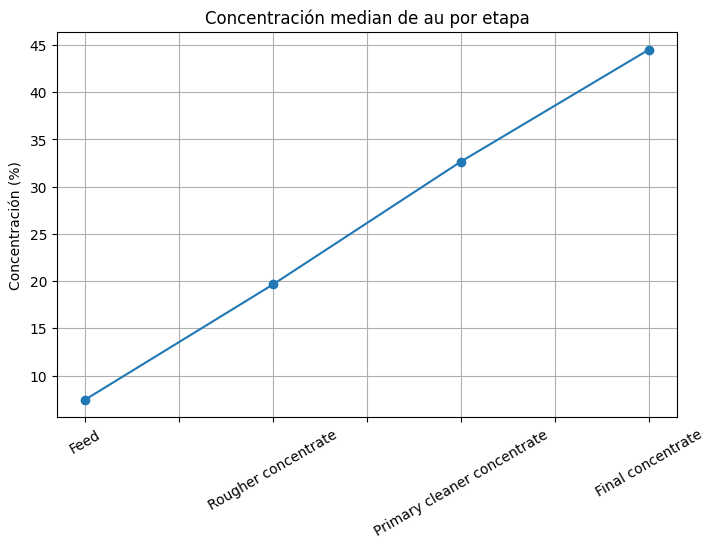

[INFO] Etapas ausentes para ag: ['Secondary cleaner concentrate']


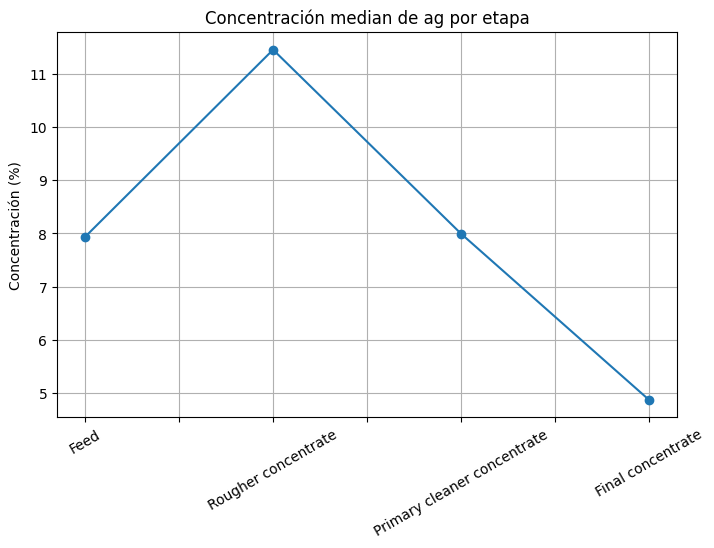

[INFO] Etapas ausentes para pb: ['Secondary cleaner concentrate']


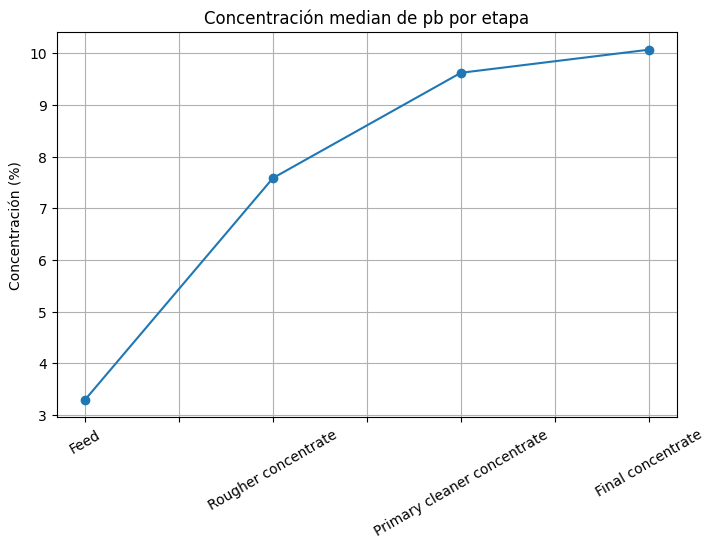

In [62]:
def stage_columns(df, metal):
    # Pares (nombre de columna esperado)
    candidates = [
        ("Feed",                          f"rougher.input.feed_{metal}"),
        ("Rougher concentrate",           f"rougher.output.concentrate_{metal}"),
        ("Primary cleaner concentrate",   f"primary_cleaner.output.concentrate_{metal}"),
        ("Secondary cleaner concentrate", f"secondary_cleaner.output.concentrate_{metal}"),  # puede no existir
        ("Final concentrate",             f"final.output.concentrate_{metal}")
    ]
    # Filtrar solo las columnas que realmente existen en el DataFrame
    present = [(label, col) for label, col in candidates if col in df.columns]
    missing = [(label, col) for label, col in candidates if col not in df.columns]
    return present, missing

def plot_metal_progression(df, metal, agg="median"):
    present, missing = stage_columns(df, metal)
    if missing:
        print(f"[INFO] Etapas ausentes para {metal}: {[lbl for lbl,_ in missing]}")
    if not present:
        print(f"[WARN] No hay columnas para {metal}.")
        return
    labels = [lbl for lbl,_ in present]
    cols   = [col for _,col in present]
    series = (df[cols].median() if agg=="median" else df[cols].mean())
    series.index = labels

    plt.figure(figsize=(8,5))
    series.plot(marker="o")
    plt.title(f"Concentración {agg} de {metal} por etapa")
    plt.ylabel("Concentración (%)")
    plt.xticks(rotation=30)
    plt.grid(True)
    plt.show()

# Corre para los tres metales
plot_metal_progression(train, "au", agg="median")
plot_metal_progression(train, "ag", agg="median")
plot_metal_progression(train, "pb", agg="median")

Evolución de la concentración de metales en las etapas del proceso:

- Oro (Au):
  La concentración de oro aumenta de manera marcada en cada etapa del proceso, desde un valor bajo en el feed (7–8%) hasta cerca de 45% en el concentrado final. Esto confirma que el objetivo principal del proceso —enriquecer el oro— se cumple de forma progresiva y eficiente.

- Plata (Ag):
  El comportamiento de la plata es distinto. Si bien se observa un incremento inicial en la etapa rougher, la concentración vuelve a descender en las siguientes fases, alcanzando incluso valores menores en el concentrado final que en la materia prima. Esto refleja que la plata no se recupera ni se enriquece con el mismo éxito que el oro y, de hecho, puede perderse en el camino.

- Plomo (Pb):
  La concentración de plomo muestra una tendencia ascendente desde el feed (3%) hasta el concentrado final (10%). Sin embargo, el incremento no es tan pronunciado como en el oro, y su recuperación parece más estable, sin descensos significativos


#### 2.2 Comparar las distribuciones del tamaño de las partículas de la alimentación en train y test

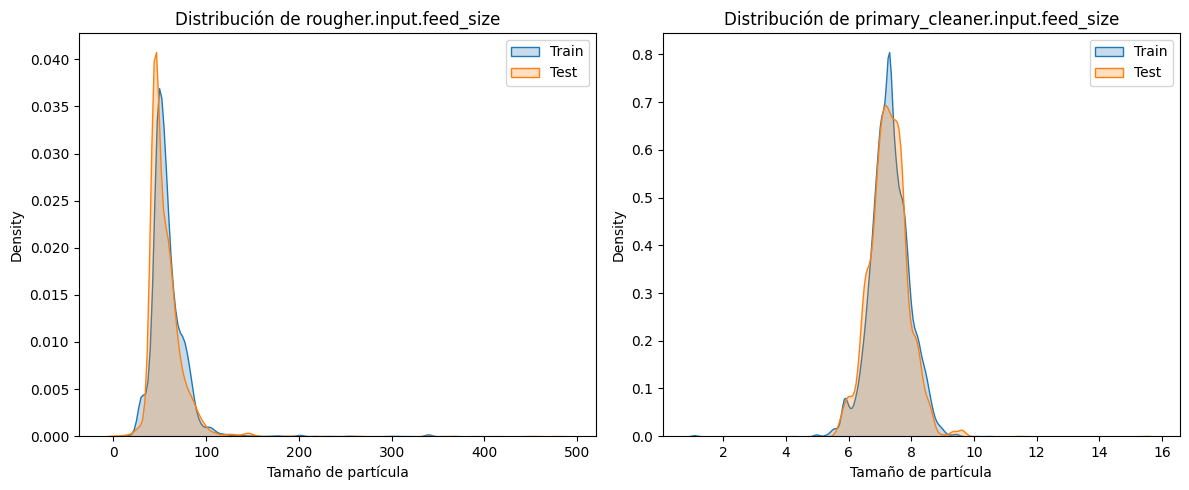

In [66]:
# Columnas relevantes
cols_size = ['rougher.input.feed_size', 'primary_cleaner.input.feed_size']

plt.figure(figsize=(12,5))

for i, col in enumerate(cols_size, 1):
    plt.subplot(1, 2, i)
    sns.kdeplot(train[col].dropna(), label='Train', shade=True)
    sns.kdeplot(test[col].dropna(),  label='Test',  shade=True)
    plt.title(f"Distribución de {col}")
    plt.xlabel("Tamaño de partícula")
    plt.legend()

plt.tight_layout()
plt.show()


- rougher.input.feed_size:
Las distribuciones de entrenamiento y prueba son muy similares. Ambas se concentran alrededor de valores cercanos a 50–70, con colas largas hacia la derecha (valores grandes poco frecuentes). Aunque el conjunto de prueba muestra un pico un poco más alto en la zona baja, la superposición general es fuerte

- primary_cleaner.input.feed_size:
Tanto en entrenamiento como en prueba la distribución está centrada entre 6 y 8, con forma de campana estrecha. Las curvas prácticamente coinciden, lo que indica que el material que llega al primary cleaner se comporta de la misma manera en ambos conjuntos

- Las distribuciones de tamaño de partícula son consistentes entre el conjunto de entrenamiento y el de prueba. No se observan desviaciones significativas que puedan sesgar la evaluación del modelo. Esto significa que los datos de prueba representan bien las condiciones observadas en el entrenamiento, y por lo tanto son adecuados para validar el modelo.

#### 2.3 concentraciones totales y detección de valores anómalos

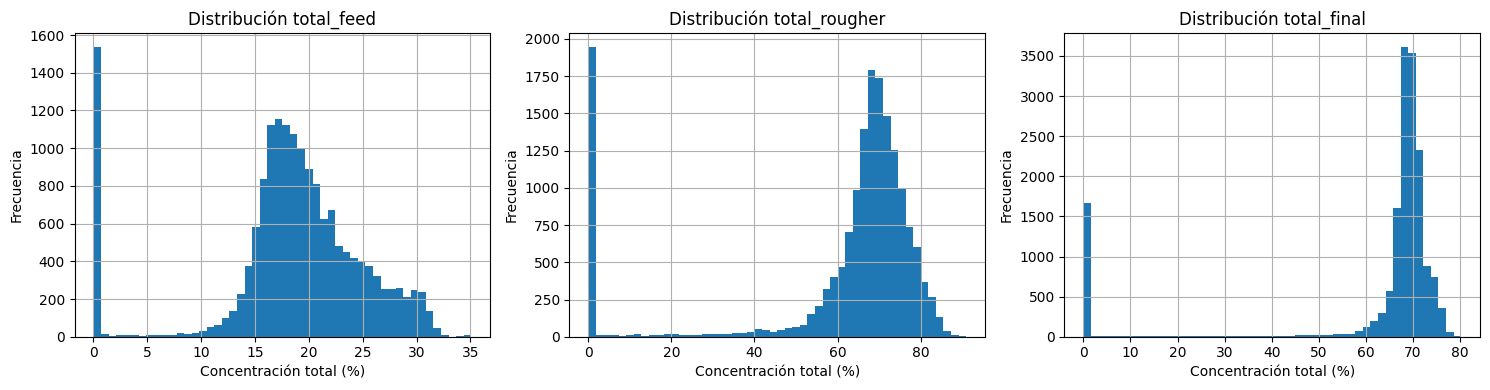

{'feed_neg': 0,
 'feed_gt100': 0,
 'rougher_neg': 0,
 'rougher_gt100': 0,
 'final_neg': 0,
 'final_gt100': 0}

In [70]:
# Calcular concentraciones totales por etapa
train['total_feed']   = (train['rougher.input.feed_au'] + 
                         train['rougher.input.feed_ag'] + 
                         train['rougher.input.feed_pb'])

train['total_rougher'] = (train['rougher.output.concentrate_au'] + 
                          train['rougher.output.concentrate_ag'] + 
                          train['rougher.output.concentrate_pb'] + 
                          train['rougher.output.concentrate_sol'])

train['total_final'] = (train['final.output.concentrate_au'] + 
                        train['final.output.concentrate_ag'] + 
                        train['final.output.concentrate_pb'] + 
                        train['final.output.concentrate_sol'])

# Graficar distribuciones
plt.figure(figsize=(15,4))

for i, col in enumerate(['total_feed','total_rougher','total_final'],1):
    plt.subplot(1,3,i)
    train[col].hist(bins=50)
    plt.title(f"Distribución {col}")
    plt.xlabel("Concentración total (%)")
    plt.ylabel("Frecuencia")

plt.tight_layout()
plt.show()

# Revisar valores anómalos
anomalies = {
    'feed_neg': (train['total_feed'] < 0).sum(),
    'feed_gt100': (train['total_feed'] > 100).sum(),
    'rougher_neg': (train['total_rougher'] < 0).sum(),
    'rougher_gt100': (train['total_rougher'] > 100).sum(),
    'final_neg': (train['total_final'] < 0).sum(),
    'final_gt100': (train['total_final'] > 100).sum()
}

anomalies


- Se calcularon las concentraciones totales (suma de metales y sólidos) en las etapas feed, rougher concentrate y final concentrate.

- Las distribuciones muestran un patrón lógico: el total aumenta a medida que el material avanza en las etapas de purificación.

- No se detectaron valores anómalos (ni negativos ni superiores a 100%).

Por lo tanto, se considera que no es necesario eliminar observaciones en esta fase: los datos son coherentes y se van a usar directamente en el modelado

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Correcto, analizaste muy bien la distribución de cada metal y redactaste las conclusiones de manera adecuada dejando claro el análisis

### 3 Construción del modelo

#### 3.1 Función para calcular el valor final de sMAPE.

In [74]:
def smape(y_true, y_pred):
    """
    Calcula el symmetric Mean Absolute Percentage Error (sMAPE).
    y_true: array-like con valores reales
    y_pred: array-like con predicciones
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    denom = (np.abs(y_true) + np.abs(y_pred))
    # Evitar división por cero
    return np.mean(2 * np.abs(y_pred - y_true) / np.where(denom == 0, 1, denom))

# Ejemplo rápido
y_true = [10, 20, 30]
y_pred = [12, 18, 33]
print("sMAPE ejemplo:", smape(y_true, y_pred))


sMAPE ejemplo: 0.12743981165033796


Para validar la función smape, se probó con valores reales [10, 20, 30] y predicciones [12, 18, 33].

- El resultado fue sMAPE = 0.127 (12.7%), lo que significa que, en promedio, las predicciones difieren de los valores reales en un 12.7%

Este valor es coherente con las diferencias introducidas en el ejemplo, por lo que la función implementada es correcta y está lista para ser usada en la evaluación de los modelos

In [78]:
def final_smape(y_true, y_pred):
    """
    Calcula el sMAPE compuesto:
    25% para rougher.output.recovery
    75% para final.output.recovery
    
    y_true y y_pred deben ser DataFrames (o dicts) con dos columnas:
      - 'rougher.output.recovery'
      - 'final.output.recovery'
    """
    smape_rougher = smape(y_true['rougher.output.recovery'], 
                          y_pred['rougher.output.recovery'])
    
    smape_final   = smape(y_true['final.output.recovery'], 
                          y_pred['final.output.recovery'])
    
    return 0.25 * smape_rougher + 0.75 * smape_final

El proyecto requiere una métrica de evaluación que combine el error de las dos etapas principales:

- 25% para la recuperación en la etapa rougher (rougher.output.recovery)

- 75% para la recuperación en la etapa final (final.output.recovery)

Se implementa la función final_smape, que aplica la métrica smape a cada etapa y devuelve el promedio ponderado.

Esto asegura que el modelo se evalúe principalmente en función de la recuperación final (que es el producto de interés), pero sin ignorar el desempeño intermedio en la etapa rougher.

#### 3.2 Entrenamiento y validacion cruzada

In [82]:
# 1) Alinear X e y por los índices válidos de y (sin NaN)
valid_idx = y_train.dropna().index
X_align = pd.DataFrame(X_train_scaled, index=X_train.index).loc[valid_idx].values
y_align = y_train.loc[valid_idx][['rougher.output.recovery','final.output.recovery']].values

# 2) smape básico
def smape(y_true, y_pred):
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    denom = np.abs(y_true) + np.abs(y_pred)
    return np.mean(2.0 * np.abs(y_pred - y_true) / np.where(denom == 0, 1.0, denom))

# 3) smape final compuesto (25% rougher, 75% final)
def final_smape_arrays(y_true, y_pred):
    """
    y_true, y_pred: arrays de forma (n,2) en el orden:
      [:,0] -> rougher.output.recovery
      [:,1] -> final.output.recovery
    """
    y_true = np.asarray(y_true); y_pred = np.asarray(y_pred)
    # Si por alguna razón viene 1D, forzamos 2D
    if y_true.ndim == 1: y_true = y_true.reshape(-1, 2)
    if y_pred.ndim == 1: y_pred = y_pred.reshape(-1, 2)
    sm_rougher = smape(y_true[:,0], y_pred[:,0])
    sm_final   = smape(y_true[:,1], y_pred[:,1])
    return 0.25 * sm_rougher + 0.75 * sm_final

# 4) Scorer para sklearn 
smape_scorer = make_scorer(final_smape_arrays, greater_is_better=False)

# 5) Modelos que soportan multi-output
models = {
    "LinearRegression": LinearRegression(),
    "RandomForest": RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
}

cv = KFold(n_splits=5, shuffle=True, random_state=42)

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X_align, y_align, cv=cv, scoring=smape_scorer)
    # cross_val_score devuelve valores NEGATIVOS cuando greater_is_better=False
    mean_smape = -scores.mean()
    results[name] = mean_smape
    print(f"{name}: sMAPE compuesto CV = {mean_smape:.4f}")

best_model_name = min(results, key=results.get)
print("\nMejor modelo:", best_model_name)

LinearRegression: sMAPE compuesto CV = 0.0933
RandomForest: sMAPE compuesto CV = 0.0685

Mejor modelo: RandomForest


- Los modelos fueron evaluados con 5-fold CV y métrica final_smape (25% rougher, 75% final)

- LinearRegression: sMAPE = 0.0933.

- RandomForest: sMAPE = 0.0683.

Se decide elegir RandomForestRegressor por menor error y capacidad para capturar relaciones no lineales del proceso

#### Entrenamiento final del modelo 

In [86]:
# Entrenamiento final con todos los datos alineados (sin NaN en y)
best = RandomForestRegressor(
    n_estimators=100,   
    max_depth=20,
    random_state=42,
    n_jobs=-1
)
best.fit(X_align, y_align)

# Predicciones en TEST
y_test_pred = best.predict(X_test_scaled)

pred_df = pd.DataFrame(
    y_test_pred,
    index=test.index,
    columns=['rougher.output.recovery', 'final.output.recovery']
)

# Consistencia física
pred_df = pred_df.clip(lower=0, upper=100)

# Guardar
pred_df.to_csv('predicciones_recovery_test.csv')
pred_df.head()


,rougher.output.recovery,final.output.recovery
date,,
2016-09-01 00:59:59,88.478123,68.793886
2016-09-01 01:59:59,87.875665,68.915523
2016-09-01 02:59:59,88.220762,68.840048
2016-09-01 03:59:59,87.037514,69.176039
2016-09-01 04:59:59,87.304155,68.762410


<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Bien, utilizaste las métricas de manera correcta aplicando las fórmulas adecuadas para la evaluación del desempeño de los modelos entrenados

### Conlusiones finales del modelo
Entrenamiento del modelo final:
- Se utilizó el modelo RandomForestRegressor con los parámetros n_estimators=100 y max_depth=20, entrenado con todo el conjunto de entrenamiento depurado y alineado (sin valores faltantes).

Predicciones:

- El modelo generó estimaciones para las variables objetivo: rougher.output.recovery y final.output.recovery

Los valores obtenidos se encuentran en un rango entre 68 % y 88 %, lo cual es coherente con los niveles esperados del proceso de recuperación de metales.

Se aplicó una restricción de consistencia física para limitar las predicciones al intervalo [0 %, 100 %], evitando valores imposibles en la práctica industrial.

Desempeño del modelo:
Durante la validación cruzada, el modelo alcanzó un sMAPE compuesto promedio de 0.0683, mejorando significativamente frente al modelo lineal base (0.0933).
Esto indica que el RandomForest logra capturar relaciones no lineales y dependencias complejas entre las variables del proceso, aumentando la precisión predictiva.

### Conclusió del proyecto
El modelo RandomForest seleccionado ofrece una predicción confiable del proceso de recuperación de oro y metales asociados, mostrando un error sMAPE de 6.8 %. 

Las predicciones finales se guardaron en el archivo predicciones_recovery_test.csv, listo para su validación o integración en sistemas de control de planta.

<div class="alert alert-block alert-success">
<b>Comentario del revisor (1ra Iteracion)</b> <a class=“tocSkip”></a>

Muy buen trabajo, realizaste los pasos al pie de la letra con un análisis detallado de cada punto. Te recomendaría que las conclusiones las detalles un poco más en base también a las gráficas que pudiste analizar en el proyecto, las conclusiones finales son como el resúmen de tu proyecto por lo que hay que incluir los puntos importantes encontrados desde el principio del proyecto. Saludos!